<a href="https://colab.research.google.com/github/RobertSilvaAlves/RobertSilvaAlves/blob/main/Supply_Chain_Optimization_for_a_FMCG_Company.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [57]:
dados = pd.read_csv('/content/FMCG_data.csv')

In [58]:
dados

,Ware_house_ID,WH_Manager_ID,Location_type,WH_capacity_size,zone,WH_regional_zone,num_refill_req_l3m,transport_issue_l1y,Competitor_in_mkt,retail_shop_num,...,electric_supply,dist_from_hub,workers_num,wh_est_year,storage_issue_reported_l3m,temp_reg_mach,approved_wh_govt_certificate,wh_breakdown_l3m,govt_check_l3m,product_wg_ton
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,1,91,29.0,NaN,13,0,A,5,15,17115
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,1,210,31.0,NaN,4,0,A,3,17,5074
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,0,161,37.0,NaN,17,0,A,6,22,23137
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,0,103,21.0,NaN,17,1,A+,3,27,22115
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,1,112,25.0,2009.0,18,0,C,6,24,24071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,WH_124995,EID_74995,Rural,Small,North,Zone 1,3,0,4,5390,...,1,142,34.0,2005.0,22,1,A,2,30,32093
24996,WH_124996,EID_74996,Rural,Mid,West,Zone 2,6,0,4,4490,...,1,130,28.0,2012.0,10,0,B,4,18,12114
24997,WH_124997,EID_74997,Urban,Large,South,Zone 5,7,0,2,5403,...,1,147,NaN,NaN,23,0,B+,5,25,27080
24998,WH_124998,EID_74998,Rural,Small,North,Zone 1,1,0,2,10562,...,1,60,25.0,NaN,18,0,A,6,30,25093


In [63]:
#Limpeza e preparação
df = dados.dropna(how='all')

df['demanda_estimada'] = df['num_refill_req_l3m'] * df['retail_shop_num']

df['indice_atendimento'] = df['product_wg_ton'] / df['demanda_estimada']

df.dtypes

,0
Ware_house_ID,object
WH_Manager_ID,object
Location_type,object
WH_capacity_size,object
zone,object
WH_regional_zone,object
num_refill_req_l3m,int64
transport_issue_l1y,int64
Competitor_in_mkt,int64
retail_shop_num,int64


In [64]:
new_column_names = {
    'Ware_house_ID': 'ID_do_armazém',
    'WH_Manager_ID': 'ID_do_gerente_do_armazém',
    'Location_type': 'Tipo_de_localização',
    'WH_capacity_size': 'Tamanho_da_capacidade_do_armazém',
    'zone': 'Zona',
    'WH_regional_zone': 'Zona_regional_do_armazém',
    'num_refill_req_l3m': 'Número_de_necessidades_de_reabastecimento_l3m',
    'transport_issue_l1y': 'Problema_de_transporte_l1y',
    'Competitor_in_mkt': 'Concorrente_no_mercado',
    'retail_shop_num': 'Número_da_loja_de_varejo',
    'wh_owner_type': 'Tipo_de_proprietário_do_armazém',
    'distributor_num': 'Número_do_distribuidor',
    'flood_impacted': 'Afetado_por_inundações',
    'flood_proof': 'À_prova_de_inundações',
    'electric_supply': 'Fornecimento_de_energia_elétrica',
    'dist_from_hub': 'Distribuído_do_centro_de_distribuição',
    'workers_num': 'Número_de_funcionários',
    'wh_est_year': 'Ano_de_est._do_armazém',
    'storage_issue_reported_l3m': 'Problema_de_armazenamento_relatado_l3m',
    'temp_reg_mach': 'Máquina_de_regulação_de_temporização',
    'approved_wh_govt_certificate': 'Certificado_governamental_aprovado_do_armazém',
    'wh_breakdown_l3m': 'Avaria_do_armazém_l3m',
    'govt_check_l3m': 'Verificação_governamental_l3m',
    'product_wg_ton': 'Peso_do_produto_em_toneladas'
}

df = df.rename(columns=new_column_names)
display(df.head())

,ID_do_armazém,ID_do_gerente_do_armazém,Tipo_de_localização,Tamanho_da_capacidade_do_armazém,Zona,Zona_regional_do_armazém,Número_de_necessidades_de_reabastecimento_l3m,Problema_de_transporte_l1y,Concorrente_no_mercado,Número_da_loja_de_varejo,...,Número_de_funcionários,Ano_de_est._do_armazém,Problema_de_armazenamento_relatado_l3m,Máquina_de_regulação_de_temporização,Certificado_governamental_aprovado_do_armazém,Avaria_do_armazém_l3m,Verificação_governamental_l3m,Peso_do_produto_em_toneladas,demanda_estimada,indice_atendimento
0,WH_100000,EID_50000,Urban,Small,West,Zone 6,3,1,2,4651,...,29.0,NaN,13,0,A,5,15,17115,13953,1.226618
1,WH_100001,EID_50001,Rural,Large,North,Zone 5,0,0,4,6217,...,31.0,NaN,4,0,A,3,17,5074,0,inf
2,WH_100002,EID_50002,Rural,Mid,South,Zone 2,1,0,4,4306,...,37.0,NaN,17,0,A,6,22,23137,4306,5.373200
3,WH_100003,EID_50003,Rural,Mid,North,Zone 3,7,4,2,6000,...,21.0,NaN,17,1,A+,3,27,22115,42000,0.526548
4,WH_100004,EID_50004,Rural,Large,North,Zone 5,3,1,2,4740,...,25.0,2009.0,18,0,C,6,24,24071,14220,1.692757


In [65]:
#Feature Engineering
df['risco_ruptura'] = df['indice_atendimento'] < 0.8

df['excesso_estoque'] = df['indice_atendimento'] > 1.2




In [103]:
df_numeric = df.select_dtypes(include=np.number)
df_numeric_corr = df_numeric.corr()

In [105]:
df_numeric_corr.to_excel('df_numeric_corr.xlsx', index=False)

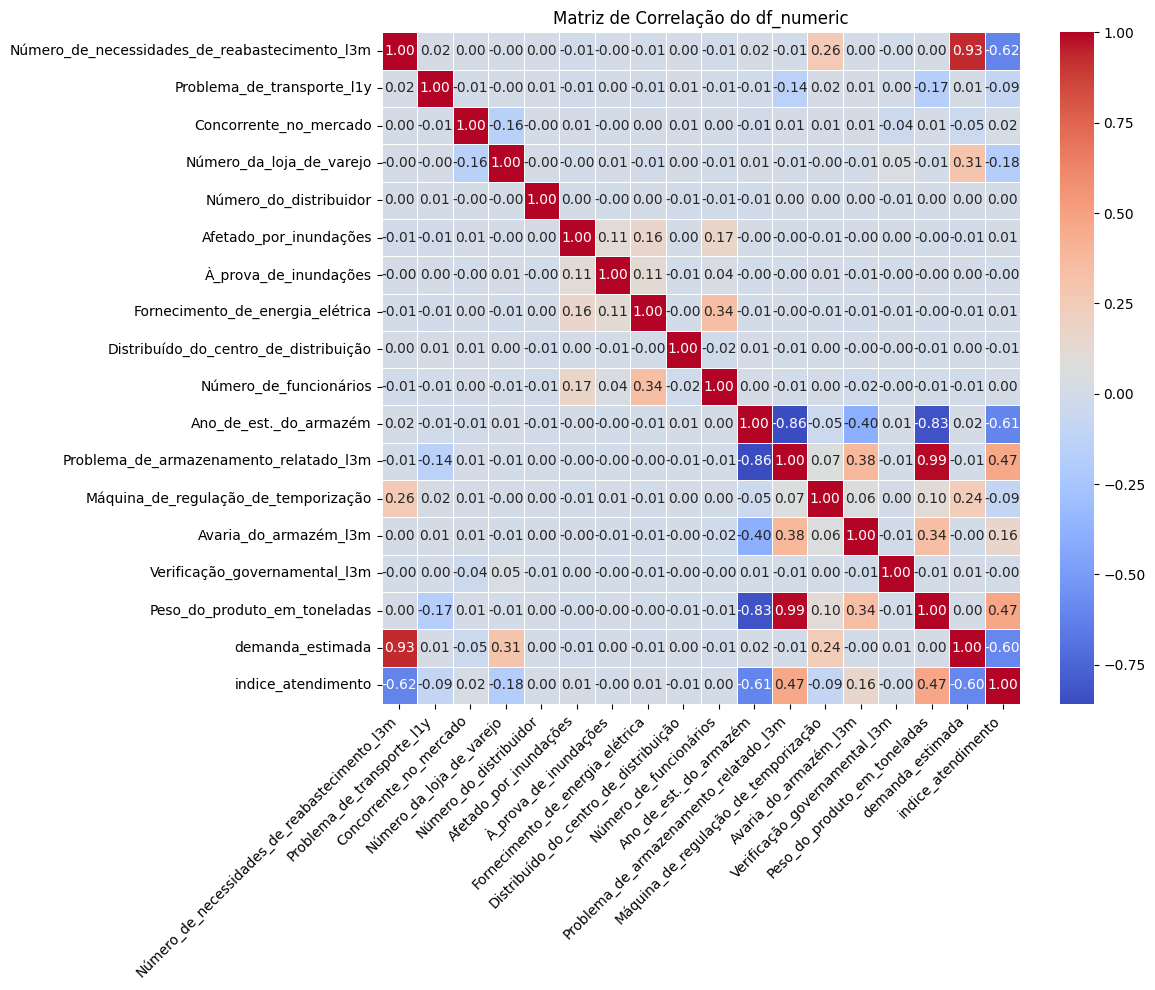

In [67]:
# Calculate the correlation matrix
correlation_matrix = df_numeric.corr()

plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlação do df_numeric')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [68]:
from sklearn.ensemble import RandomForestRegressor

In [69]:
y = df['Peso_do_produto_em_toneladas']

In [70]:
X = df.drop(columns=['Peso_do_produto_em_toneladas', 'ID_do_armazém', 'ID_do_gerente_do_armazém'])

In [71]:
X = pd.get_dummies(X)

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [107]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# Lidar com valores infinitos removendo as linhas que os contêm
# Primeiro, combine X_train e y_train para remover facilmente as linhas correspondentes
combined_train = X_train.copy()
combined_train['target'] = y_train

# Eliminar linhas onde qualquer coluna contenha o valor infinito
combined_train = combined_train.replace([np.inf, -np.inf], np.nan).dropna()

# Separar X_train e y_train novamente
X_train_cleaned = combined_train.drop(columns=['target'])
y_train_cleaned = combined_train['target']

model = RandomForestRegressor()
model.fit(X_train_cleaned, y_train_cleaned)

RandomForestRegressor()

In [108]:
# Limpe X_test da mesma forma que X_train foi limpo
X_test_cleaned = X_test.copy()
X_test_cleaned = X_test_cleaned.replace([np.inf, -np.inf], np.nan).dropna()

# Faça previsões usando o teste X limpo
y_pred = model.predict(X_test_cleaned)

In [109]:
from sklearn.metrics import mean_absolute_error

# Filtrar y_test para corresponder aos índices limpos de X_test_cleaned
y_test_filtered = y_test.loc[X_test_cleaned.index]

erro = mean_absolute_error(y_test_filtered, y_pred)
print("Erro médio:", erro)

Erro médio: 646.4948477564102


In [80]:
df['Peso_do_produto_em_toneladas'].mean()

np.float64(22102.63292)

In [114]:
import numpy as np

mape = np.mean(np.abs((y_test_filtered - y_pred) / y_test_filtered)) * 100
print("Erro percentual:", mape)

Erro percentual: 3.062567025861005


In [84]:
df_result = pd.DataFrame({
    'Real': y_test_filtered,
    'Previsto': y_pred
})

df_result['Diferença'] = df_result['Previsto'] - df_result['Real']

In [86]:
df_result

,Real,Previsto,Diferença
6868,6058,6107.90,49.90
24016,17073,16845.93,-227.07
9668,11101,10681.06,-419.94
7488,35104,32215.69,-2888.31
5804,51126,52011.13,885.13
...,...,...,...
2644,25127,23830.83,-1296.17
2315,34136,34406.93,270.93
11917,31113,30612.54,-500.46
9136,29075,27186.55,-1888.45


In [106]:
df_result.to_excel('df_result.xlsx', index=False)